In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
titanic = pd.read_csv("D:\\project\\Github_repository\\titanic-survival-classification\\titanic-survival-classification\\src\\titanic.csv")
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [63]:
titanic.shape

(1310, 14)

In [64]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   str    
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    str    
 10  embarked   1307 non-null   str    
 11  boat       486 non-null    str    
 12  body       121 non-null    float64
 13  home.dest  745 non-null    str    
dtypes: float64(7), str(7)
memory usage: 210.9 KB


In [65]:
titanic.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [66]:
print(f"unique : {titanic['survived'].unique()}")
print(f"Quantity of null: {titanic['survived'].isna().sum()}")
print(f"index null number: {titanic[titanic['survived'].isna()].index}")
print(f"Quantity of survived: {titanic[titanic['survived'] == 1].value_counts()}")
print(f"Quantity of Drowning: {titanic[titanic['survived'] == 0].value_counts()}")

unique : [ 1.  0. nan]
Quantity of null: 1
index null number: RangeIndex(start=1309, stop=1310, step=1)
Quantity of survived: Series([], Name: count, dtype: int64)
Quantity of Drowning: Series([], Name: count, dtype: int64)


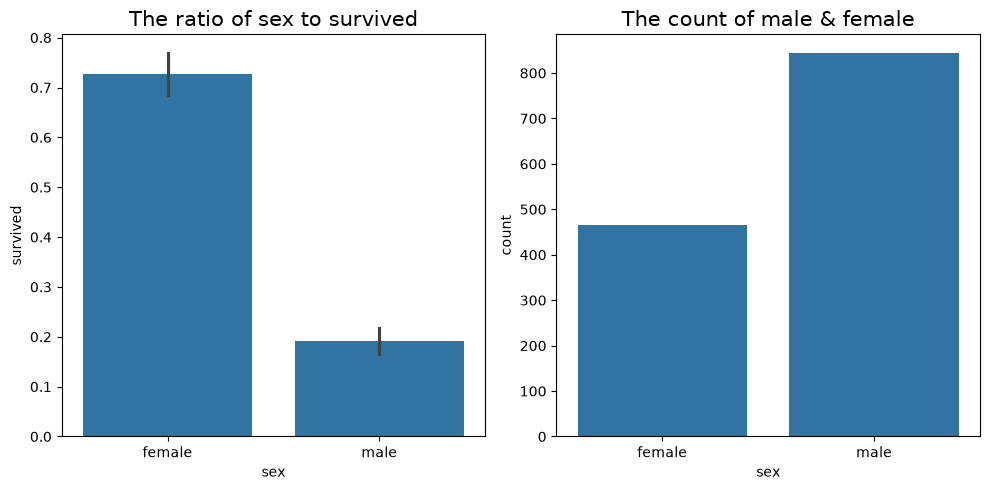

In [67]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=titanic, x='sex', y='survived', ax=axs[0])
axs[0].set_title('The ratio of sex to survived', size=15)

sns.countplot(data=titanic, x='sex', ax=axs[1])
axs[1].set_title('The count of male & female', size=15)

fig.tight_layout()

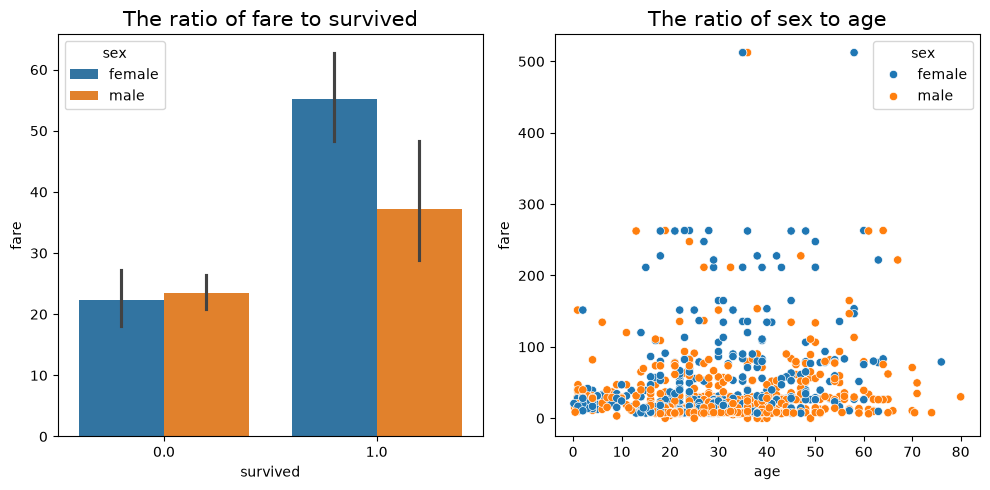

In [68]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=titanic, x='survived', y='fare', hue='sex', ax=axs[0])
axs[0].set_title('The ratio of fare to survived', size=15)

sns.scatterplot(data=titanic, x='age', y='fare', hue='sex', ax=axs[1])
axs[1].set_title('The ratio of sex to age', size=15)

fig.tight_layout()

In [69]:
titanic['ticket'].value_counts()

ticket
CA. 2343        11
1601             8
CA 2144          8
PC 17608         7
S.O.C. 14879     7
                ..
2628             1
2647             1
2656             1
2670             1
315082           1
Name: count, Length: 929, dtype: int64

In [70]:
titanic.iloc[1309]

pclass       NaN
survived     NaN
name         NaN
sex          NaN
age          NaN
sibsp        NaN
parch        NaN
ticket       NaN
fare         NaN
cabin        NaN
embarked     NaN
boat         NaN
body         NaN
home.dest    NaN
Name: 1309, dtype: object

In [71]:
titanic = titanic.drop(titanic.index[1309])

In [72]:
titanic.isna().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

<Axes: >

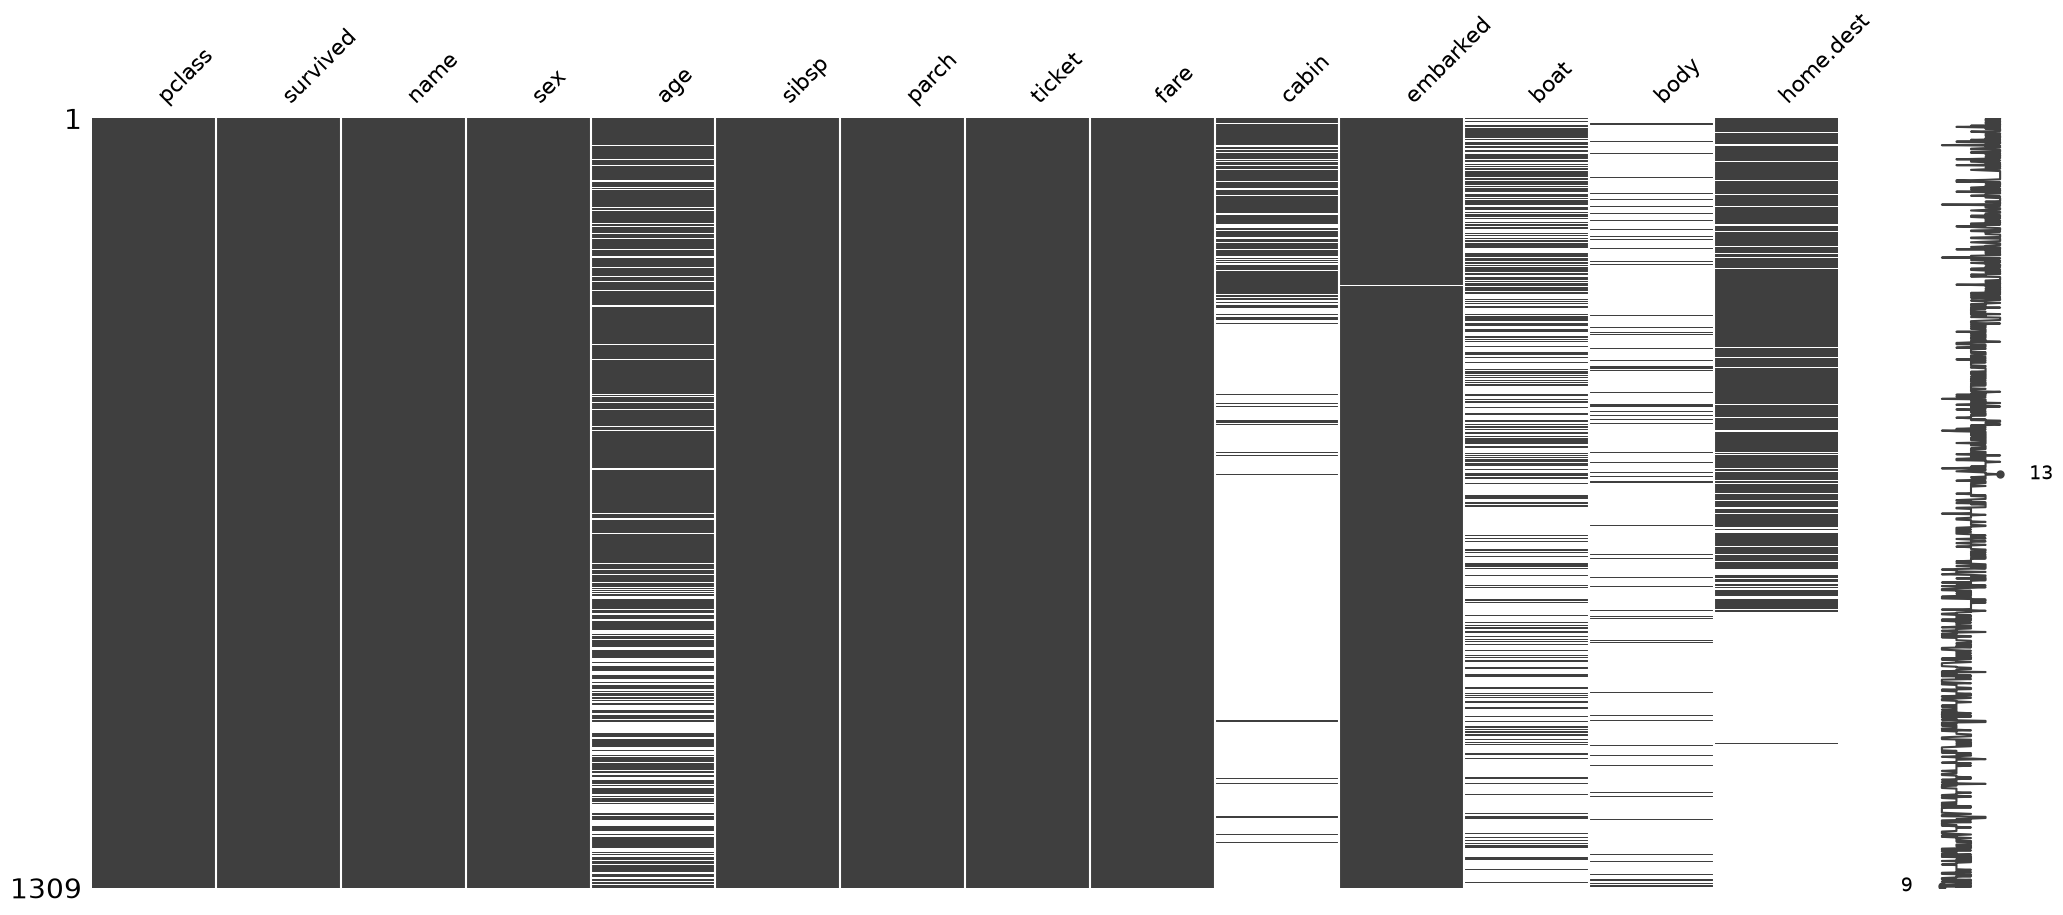

In [73]:
import missingno as msno

msno.matrix(titanic)

In [74]:
titanic['cabin'].value_counts().sum()

np.int64(295)

In [75]:
def drop_missing_columns(df, threshold=50):
    dropped_columns = []

    for col in df.columns:
        if df[col].isnull().mean() * 100 > threshold:
            dropped_columns.append(col)
            df.drop(columns =col, inplace=True)

    return dropped_columns

drop_missing_columns(titanic)

['cabin', 'boat', 'body']

In [76]:
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,S,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.5000,1.0,0.0,2665,14.4542,C,NaN
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,C,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,C,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,C,NaN


In [77]:
titanic.isna().sum()

pclass         0
survived       0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
embarked       2
home.dest    564
dtype: int64

In [78]:
titanic['fare'] = titanic['fare'].fillna(titanic['fare'].median())

In [79]:
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic['embarked'].isna().sum()

np.int64(0)

In [80]:
titanic['age']

0       29.0000
1        0.9167
2        2.0000
3       30.0000
4       25.0000
         ...   
1304    14.5000
1305        NaN
1306    26.5000
1307    27.0000
1308    29.0000
Name: age, Length: 1309, dtype: float64

In [81]:
titanic['age'] = titanic['age'].interpolate(method='polynomial', order=2)

In [82]:
titanic['age'] = titanic['age'].round()
titanic['age']

0       29.0
1        1.0
2        2.0
3       30.0
4       25.0
        ... 
1304    14.0
1305    18.0
1306    26.0
1307    27.0
1308    29.0
Name: age, Length: 1309, dtype: float64

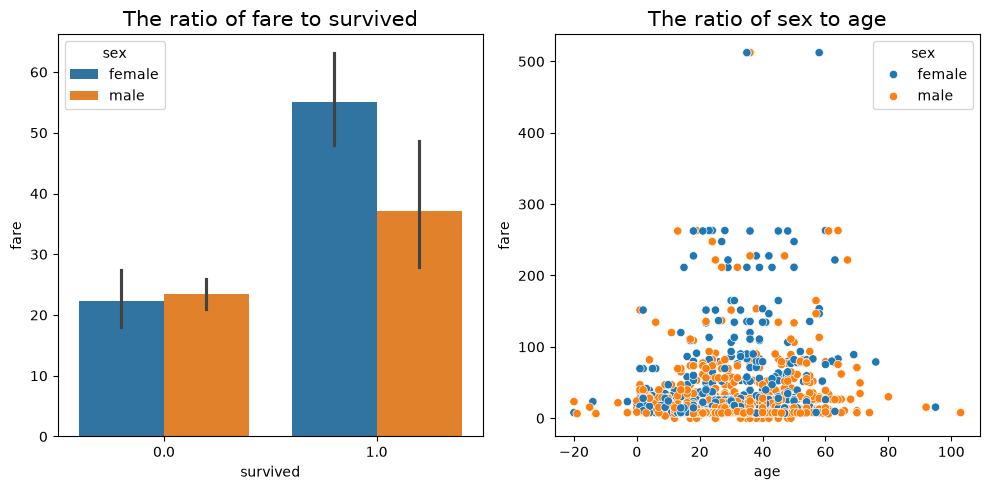

In [83]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=titanic, x='survived', y='fare', hue='sex', ax=axs[0])
axs[0].set_title('The ratio of fare to survived', size=15)

sns.scatterplot(data=titanic, x='age', y='fare', hue='sex', ax=axs[1])
axs[1].set_title('The ratio of sex to age', size=15)

fig.tight_layout()

In [84]:
titanic.isna().sum()

pclass         0
survived       0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
embarked       0
home.dest    564
dtype: int64

In [85]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1309 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   str    
 8   fare       1309 non-null   float64
 9   embarked   1309 non-null   str    
 10  home.dest  745 non-null    str    
dtypes: float64(6), str(5)
memory usage: 177.9 KB


In [86]:
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0,0.0,0.0,24160,211.3375,S,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,1.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"


In [87]:
titanic['alone'] = ((titanic['sibsp'] == 0) & (titanic['parch'] == 0))
titanic['alone']

0        True
1       False
2       False
3       False
4       False
        ...  
1304    False
1305    False
1306     True
1307     True
1308     True
Name: alone, Length: 1309, dtype: bool

In [88]:
titanic['FamilySize'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['FamilySize']

0       1.0
1       4.0
2       4.0
3       4.0
4       4.0
       ... 
1304    2.0
1305    2.0
1306    1.0
1307    1.0
1308    1.0
Name: FamilySize, Length: 1309, dtype: float64

In [89]:
label = ['infant', 'toddler', 'child', 'teen', 'adult', 'middle_age', 'senior', 'old']
bin = [0, 1, 4, 12, 18, 39, 59, 74, np.inf]
titanic['age_group'] = pd.cut(titanic['age'], labels=label, bins=bin)
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,alone,FamilySize,age_group
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0,0.0,0.0,24160,211.3375,S,"St Louis, MO",True,1.0,adult
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,1.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,infant
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,toddler
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.0,1.0,0.0,2665,14.4542,C,NaN,False,2.0,teen
1305,3.0,0.0,"Zabour, Miss. Thamine",female,18.0,1.0,0.0,2665,14.4542,C,NaN,False,2.0,teen
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.0,0.0,0.0,2656,7.2250,C,NaN,True,1.0,adult
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0,0.0,0.0,2670,7.2250,C,NaN,True,1.0,adult


In [90]:
titanic['NamePrefix'] = titanic['name'].str.extract(r',\s*([^.]*)\.')
titanic['name'] = titanic['name'].str.replace(r',.*?\.\s*', '', regex=True)

In [91]:
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,alone,FamilySize,age_group,NamePrefix
0,1.0,1.0,AllenElisabeth Walton,female,29.0,0.0,0.0,24160,211.3375,S,"St Louis, MO",True,1.0,adult,Miss
1,1.0,1.0,AllisonHudson Trevor,male,1.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,infant,Master
2,1.0,0.0,AllisonHelen Loraine,female,2.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,toddler,Miss
3,1.0,0.0,AllisonHudson Joshua Creighton,male,30.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mr
4,1.0,0.0,AllisonHudson J C (Bessie Waldo Daniels),female,25.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,ZabourHileni,female,14.0,1.0,0.0,2665,14.4542,C,NaN,False,2.0,teen,Miss
1305,3.0,0.0,ZabourThamine,female,18.0,1.0,0.0,2665,14.4542,C,NaN,False,2.0,teen,Miss
1306,3.0,0.0,ZakarianMapriededer,male,26.0,0.0,0.0,2656,7.2250,C,NaN,True,1.0,adult,Mr
1307,3.0,0.0,ZakarianOrtin,male,27.0,0.0,0.0,2670,7.2250,C,NaN,True,1.0,adult,Mr


In [92]:
titanic['who'] = np.select(
    [
        titanic['age'] < 16,
        titanic['sex'] == 'female'
    ],
    [
        'child',
        'woman'
    ],
    default='man'
)
titanic['who']

0       woman
1       child
2       child
3         man
4       woman
        ...  
1304    child
1305    woman
1306      man
1307      man
1308      man
Name: who, Length: 1309, dtype: str

In [93]:
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,alone,FamilySize,age_group,NamePrefix,who
0,1.0,1.0,AllenElisabeth Walton,female,29.0,0.0,0.0,24160,211.3375,S,"St Louis, MO",True,1.0,adult,Miss,woman
1,1.0,1.0,AllisonHudson Trevor,male,1.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,infant,Master,child
2,1.0,0.0,AllisonHelen Loraine,female,2.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,toddler,Miss,child
3,1.0,0.0,AllisonHudson Joshua Creighton,male,30.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mr,man
4,1.0,0.0,AllisonHudson J C (Bessie Waldo Daniels),female,25.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mrs,woman


In [94]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   pclass      1309 non-null   float64 
 1   survived    1309 non-null   float64 
 2   name        1309 non-null   str     
 3   sex         1309 non-null   str     
 4   age         1309 non-null   float64 
 5   sibsp       1309 non-null   float64 
 6   parch       1309 non-null   float64 
 7   ticket      1309 non-null   str     
 8   fare        1309 non-null   float64 
 9   embarked    1309 non-null   str     
 10  home.dest   745 non-null    str     
 11  alone       1309 non-null   bool    
 12  FamilySize  1309 non-null   float64 
 13  age_group   1295 non-null   category
 14  NamePrefix  1309 non-null   str     
 15  who         1309 non-null   str     
dtypes: bool(1), category(1), float64(7), str(7)
memory usage: 211.3 KB


In [95]:
titanic['sex'] = titanic['sex'].astype('category')
titanic['embarked'] = titanic['embarked'].astype('category')

In [96]:
titanic = pd.get_dummies(titanic, columns=['embarked'], dtype=int)
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,home.dest,alone,FamilySize,age_group,NamePrefix,who,embarked_C,embarked_Q,embarked_S
0,1.0,1.0,AllenElisabeth Walton,female,29.0,0.0,0.0,24160,211.3375,"St Louis, MO",True,1.0,adult,Miss,woman,0,0,1
1,1.0,1.0,AllisonHudson Trevor,male,1.0,1.0,2.0,113781,151.5500,"Montreal, PQ / Chesterville, ON",False,4.0,infant,Master,child,0,0,1
2,1.0,0.0,AllisonHelen Loraine,female,2.0,1.0,2.0,113781,151.5500,"Montreal, PQ / Chesterville, ON",False,4.0,toddler,Miss,child,0,0,1
3,1.0,0.0,AllisonHudson Joshua Creighton,male,30.0,1.0,2.0,113781,151.5500,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mr,man,0,0,1
4,1.0,0.0,AllisonHudson J C (Bessie Waldo Daniels),female,25.0,1.0,2.0,113781,151.5500,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mrs,woman,0,0,1


In [97]:
titanic = titanic.drop(columns=['name', 'home.dest', 'ticket'])

In [98]:
titanic['alone'] = titanic['alone'].astype(int)

In [99]:
titanic['sex_code'] = titanic['sex'].cat.codes

In [100]:
titanic['age_group'] = pd.Categorical(
    titanic['age_group'],
    categories=['infant', 'toddler', 'child', 'teen', 'adult', 'middle_age', 'senior', 'old'],
    ordered=True
)

titanic['age_group_code'] = titanic['age_group'].cat.codes

In [101]:
titanic = pd.get_dummies(
    titanic,
    columns=['who'],
    dtype=int
)

In [102]:
titanic['NamePrefix'].value_counts()

NamePrefix
Mr              757
Miss            260
Mrs             197
Master           61
Dr                8
Rev               8
Col               4
Major             2
Mlle              2
Ms                2
Mme               1
Capt              1
Lady              1
Sir               1
Dona              1
Jonkheer          1
the Countess      1
Don               1
Name: count, dtype: int64

In [103]:
titanic = pd.get_dummies(
    titanic,
    columns=['NamePrefix'],
    dtype=int
)

In [104]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   pclass                   1309 non-null   float64 
 1   survived                 1309 non-null   float64 
 2   sex                      1309 non-null   category
 3   age                      1309 non-null   float64 
 4   sibsp                    1309 non-null   float64 
 5   parch                    1309 non-null   float64 
 6   fare                     1309 non-null   float64 
 7   alone                    1309 non-null   int64   
 8   FamilySize               1309 non-null   float64 
 9   age_group                1295 non-null   category
 10  embarked_C               1309 non-null   int64   
 11  embarked_Q               1309 non-null   int64   
 12  embarked_S               1309 non-null   int64   
 13  sex_code                 1309 non-null   int8    
 14  age_group_code     

In [105]:
titanic.head()

,pclass,survived,sex,age,sibsp,parch,fare,alone,FamilySize,age_group,...,NamePrefix_Master,NamePrefix_Miss,NamePrefix_Mlle,NamePrefix_Mme,NamePrefix_Mr,NamePrefix_Mrs,NamePrefix_Ms,NamePrefix_Rev,NamePrefix_Sir,NamePrefix_the Countess
0,1.0,1.0,female,29.0,0.0,0.0,211.3375,1,1.0,adult,...,0,1,0,0,0,0,0,0,0,0
1,1.0,1.0,male,1.0,1.0,2.0,151.5500,0,4.0,infant,...,1,0,0,0,0,0,0,0,0,0
2,1.0,0.0,female,2.0,1.0,2.0,151.5500,0,4.0,toddler,...,0,1,0,0,0,0,0,0,0,0
3,1.0,0.0,male,30.0,1.0,2.0,151.5500,0,4.0,adult,...,0,0,0,0,1,0,0,0,0,0
4,1.0,0.0,female,25.0,1.0,2.0,151.5500,0,4.0,adult,...,0,0,0,0,0,1,0,0,0,0


In [106]:
abs(titanic.corr(numeric_only=True)['survived']).sort_values(ascending=False)

survived                   1.000000
NamePrefix_Mr              0.529016
sex_code                   0.528693
who_man                    0.516781
who_woman                  0.485052
NamePrefix_Mrs             0.350699
pclass                     0.312469
NamePrefix_Miss            0.302225
fare                       0.244414
alone                      0.201719
embarked_C                 0.182123
embarked_S                 0.150542
who_child                  0.100251
age_group_code             0.095977
parch                      0.082660
NamePrefix_Rev             0.061648
age                        0.058444
NamePrefix_Master          0.057436
NamePrefix_Mlle            0.049758
NamePrefix_Mme             0.035171
NamePrefix_Sir             0.035171
NamePrefix_Lady            0.035171
NamePrefix_the Countess    0.035171
NamePrefix_Dona            0.035171
sibsp                      0.027825
FamilySize                 0.026876
NamePrefix_Capt            0.021737
NamePrefix_Jonkheer        0